# House Prices - Advanced Regression Techniques

Цель данной задачи предсказать стоимость продажи жилых домов. У нас есть 80 признаков, каждый из которых описывает данный жилой дом и в некоторой степени может объяснять его стоимость. У нас есть файлик `data_description.txt`, который содержит описание наших данных

**Математическая задача** - восстановление зависимости в постановке задачи регрессии

In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor


SEED = 28

загрузим наши данные

In [3]:
data = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")

test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")

In [4]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


Определим целевую переменную

In [5]:
TARGET = "SalePrice"

In [6]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


удалим Id из наших данных, так как он нам не нужен

In [7]:
data.drop(columns=["Id"], axis=1, inplace=True)

In [8]:
print(f"Размер тренировочной выборки: {data.shape}")
print(f"Размер тестовой выборки: {test.shape}")

Размер тренировочной выборки: (1460, 80)
Размер тестовой выборки: (1459, 80)


посмотрим на общую информацию о данных

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

## EDA

посмотрим на пропуски

<Axes: >

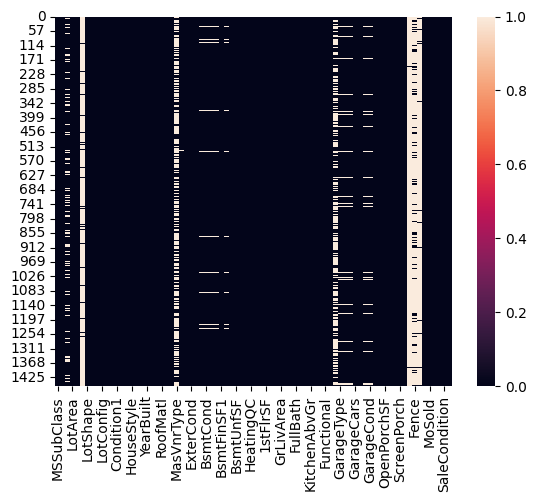

In [10]:
sns.heatmap(data.isnull())

удалим признаки, где доля пропущенных значений больше 15%

In [11]:
pass_features = data.isnull().sum() / data.shape[0]

pass_features.sort_values(ascending=False, inplace=True)

to_delete_cols = pass_features[pass_features > 0.15].index.tolist()

data.drop(columns=to_delete_cols, inplace=True)

<Axes: >

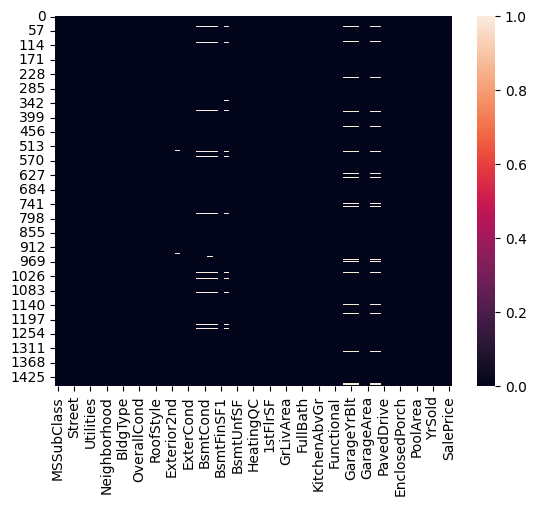

In [12]:
sns.heatmap(data.isnull())

### Descriptive statistics

In [13]:
data

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,20,RL,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,70,RL,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,20,RL,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,112,0,0,0,0,4,2010,WD,Normal,142125


построим распределение целевой переменной

<Axes: xlabel='SalePrice', ylabel='Count'>

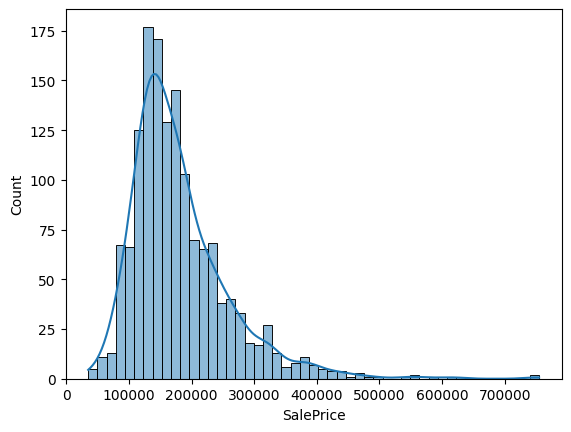

In [14]:
sns.histplot(data, x="SalePrice", kde=True)

применим логарифмирование для выравнивания распределения

<Axes: xlabel='SalePrice', ylabel='Count'>

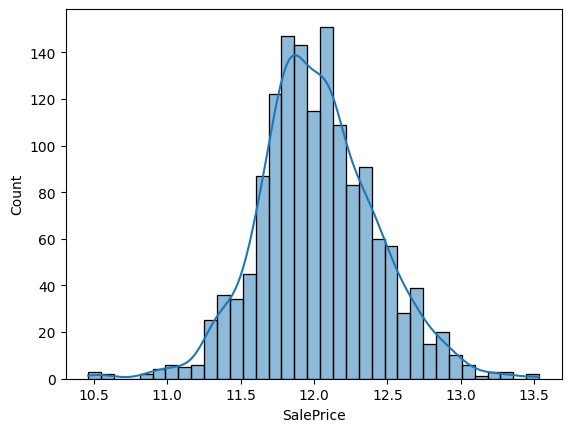

In [15]:
sns.histplot(np.log1p(data["SalePrice"]), kde=True)

In [16]:
data["SalePrice"] = np.log1p(data["SalePrice"])

Выберем числове признаки и посмотрим на корреляцию числовых признаков с таргетом

In [17]:
data.select_dtypes(include="number")

,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,8450,7,5,2003,2003,196.0,706,0,150,...,0,61,0,0,0,0,0,2,2008,12.247699
1,20,9600,6,8,1976,1976,0.0,978,0,284,...,298,0,0,0,0,0,0,5,2007,12.109016
2,60,11250,7,5,2001,2002,162.0,486,0,434,...,0,42,0,0,0,0,0,9,2008,12.317171
3,70,9550,7,5,1915,1970,0.0,216,0,540,...,0,35,272,0,0,0,0,2,2006,11.849405
4,60,14260,8,5,2000,2000,350.0,655,0,490,...,192,84,0,0,0,0,0,12,2008,12.429220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,7917,6,5,1999,2000,0.0,0,0,953,...,0,40,0,0,0,0,0,8,2007,12.072547
1456,20,13175,6,6,1978,1988,119.0,790,163,589,...,349,0,0,0,0,0,0,2,2010,12.254868
1457,70,9042,7,9,1941,2006,0.0,275,0,877,...,0,60,0,0,0,0,2500,5,2010,12.493133
1458,20,9717,5,6,1950,1996,0.0,49,1029,0,...,366,0,112,0,0,0,0,4,2010,11.864469


построим тепловую карту корреляций

<Axes: >

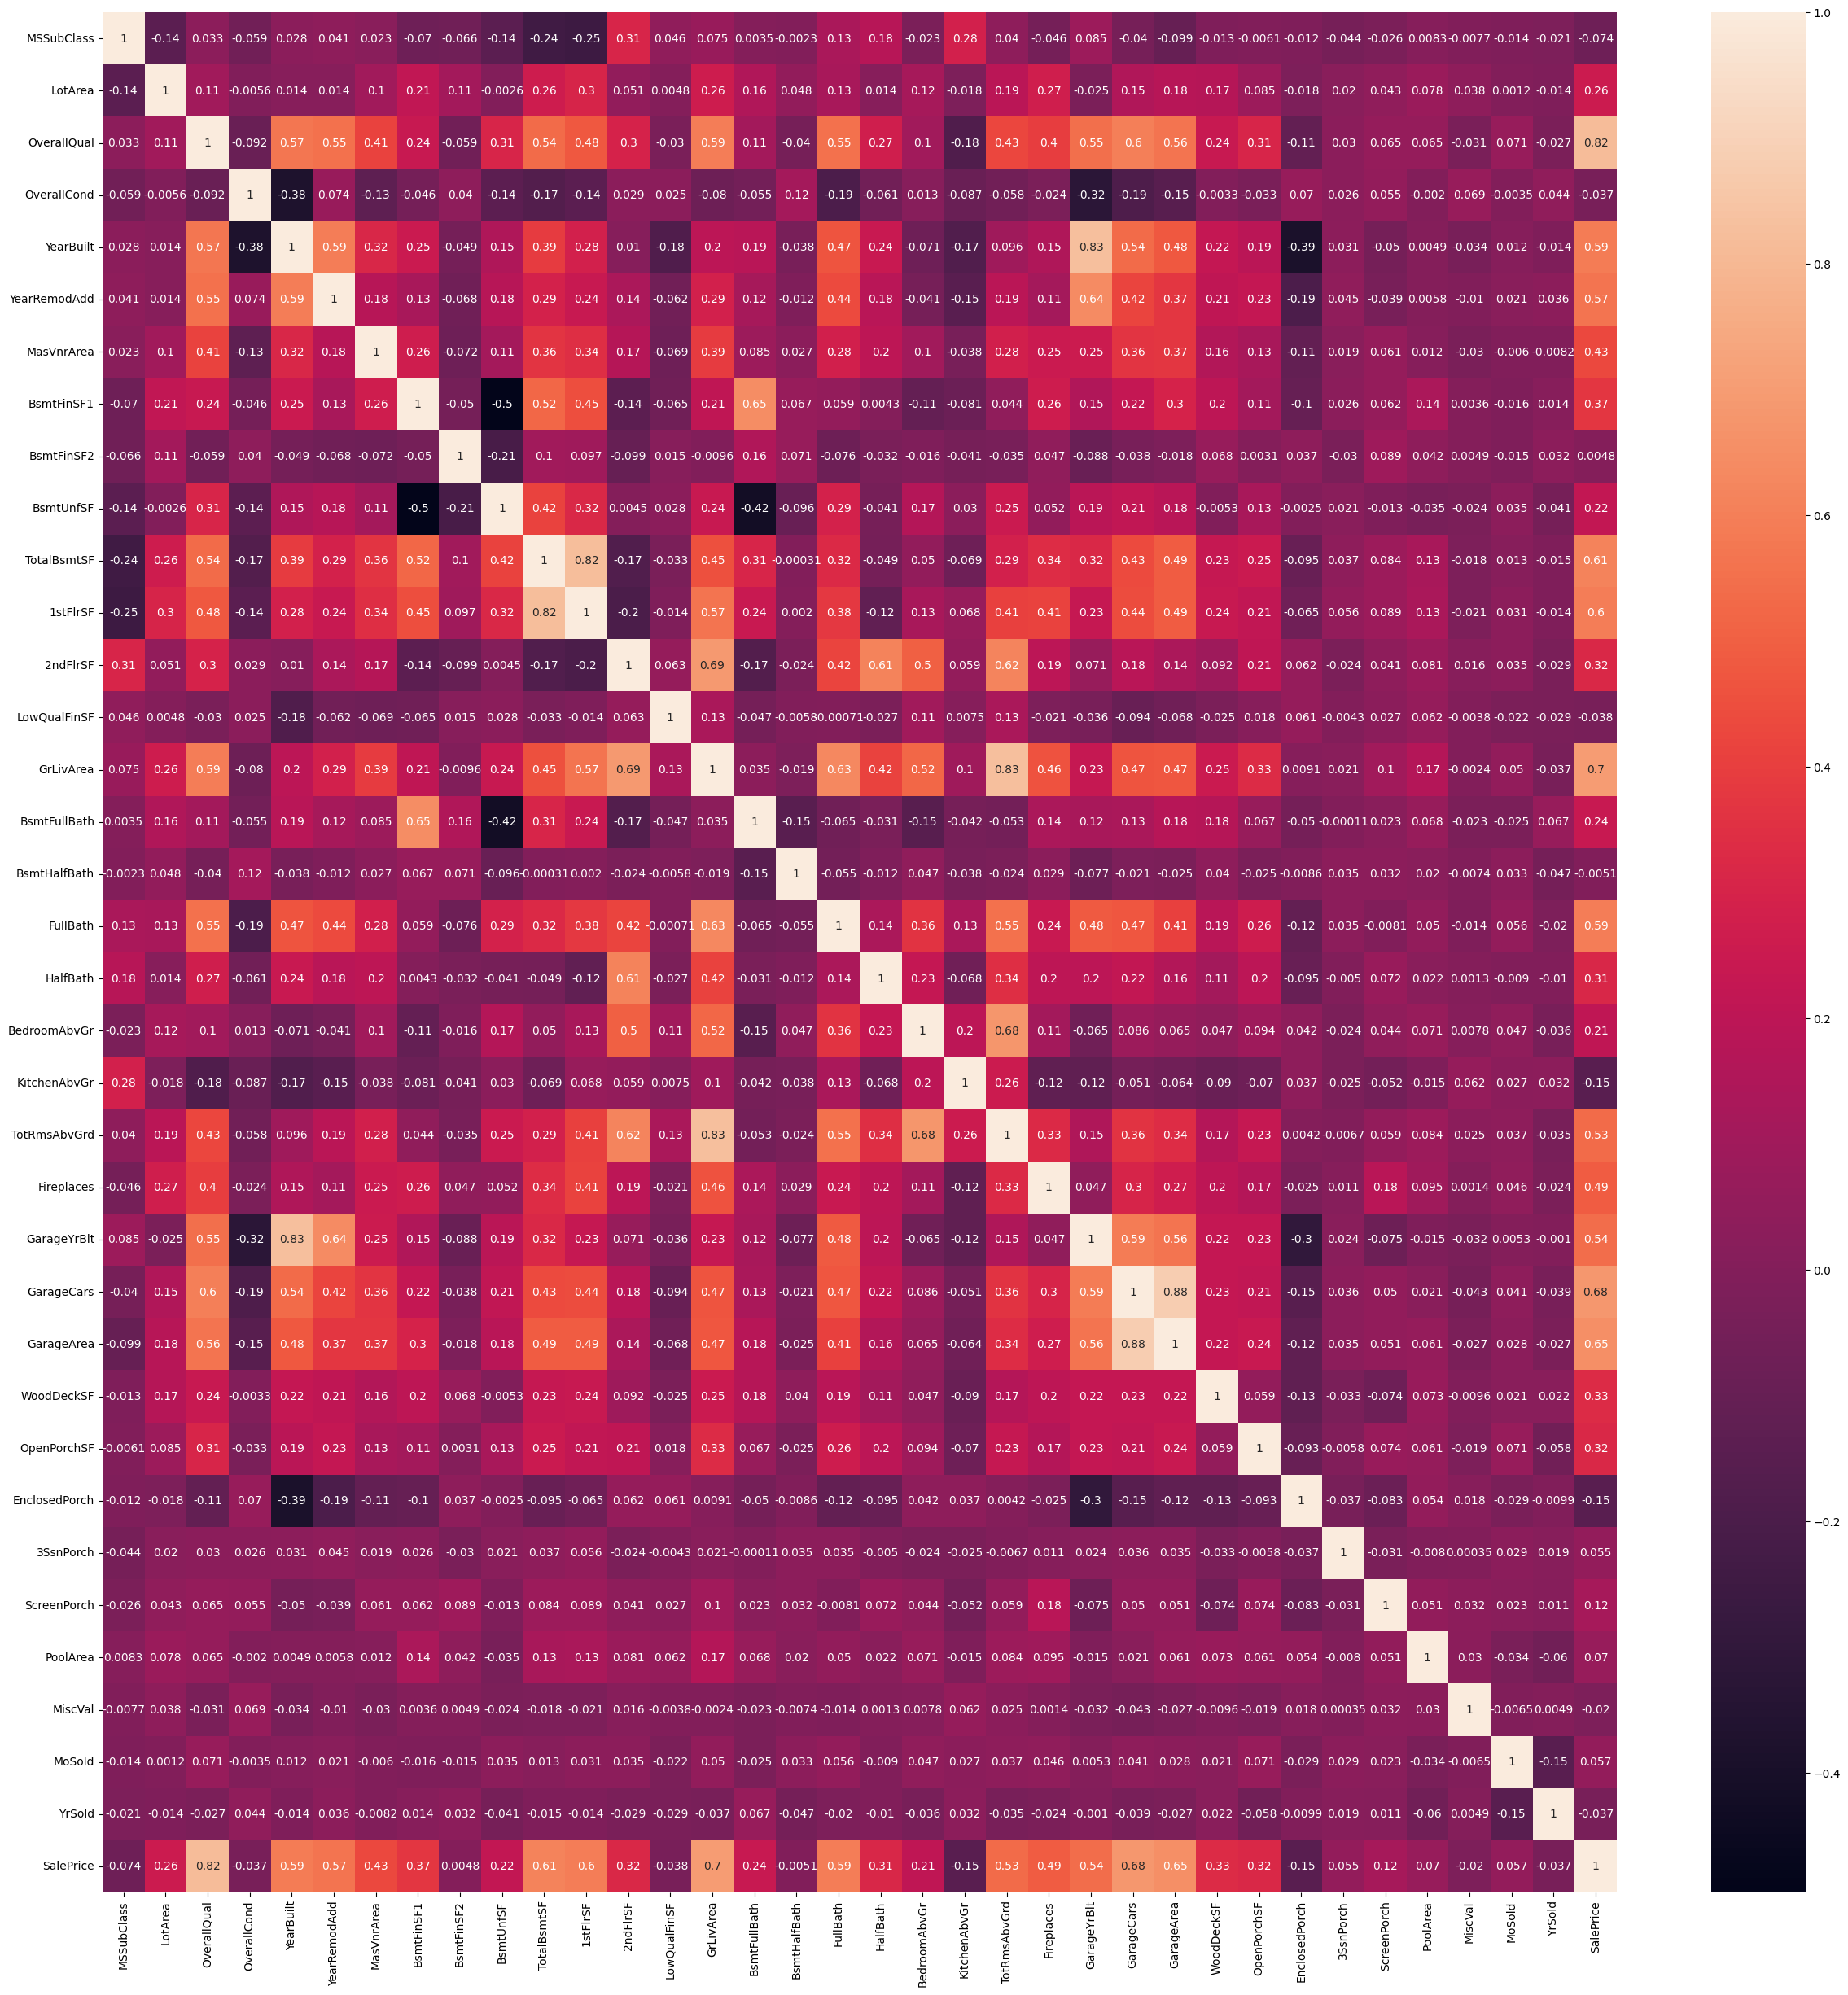

In [18]:
plt.figure(figsize=(30, 30))
sns.heatmap(data.select_dtypes(include="number").corr(), annot=True)

как видим, достаточно много признаков хорошо коррелируют с целевой переменной. Теперь возьмем признаки чья корреляция больше 0.5

In [19]:
corr_table = data.select_dtypes(include="number").corr()
sale_price_corr = corr_table["SalePrice"].drop("SalePrice")
filtered_corr_table = sale_price_corr[sale_price_corr.abs() > 0.5].sort_values(ascending=False)

In [20]:
num_cols = filtered_corr_table.index.tolist()

num_cols

['OverallQual',
 'GrLivArea',
 'GarageCars',
 'GarageArea',
 'TotalBsmtSF',
 '1stFlrSF',
 'FullBath',
 'YearBuilt',
 'YearRemodAdd',
 'GarageYrBlt',
 'TotRmsAbvGrd']

In [21]:
filtered_corr_table

OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
GarageYrBlt     0.541073
TotRmsAbvGrd    0.534422
Name: SalePrice, dtype: float64

провели некий отбор признаков по корреляционной матрице. Далее заполним пропущенные значения в признаках выше, и проведем второй отбор признаков на основе статистики

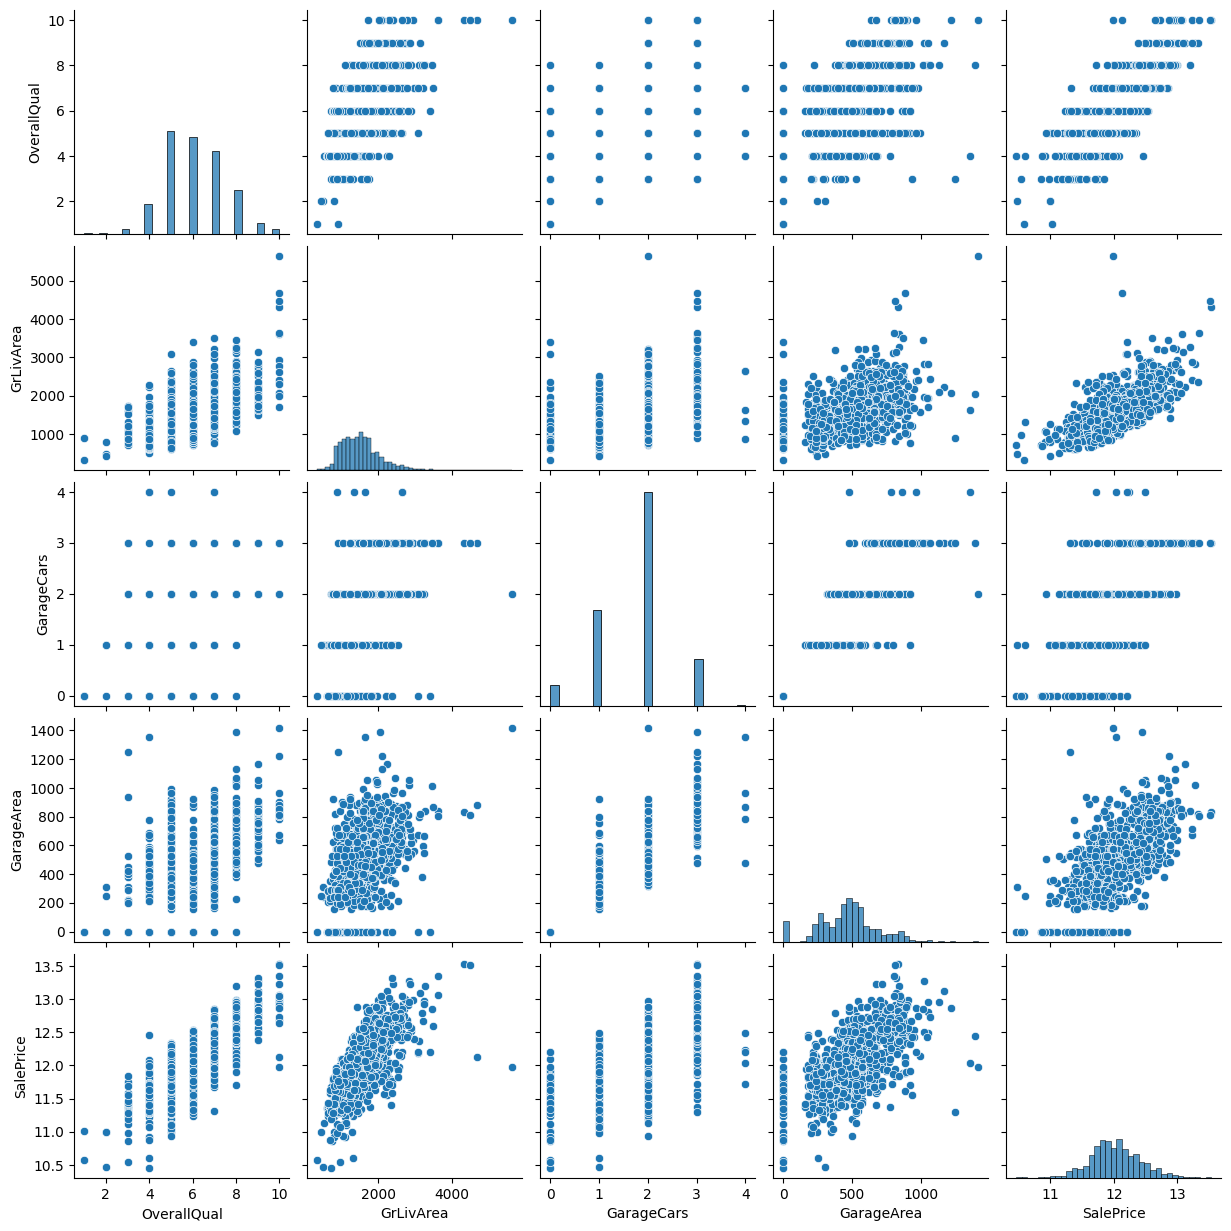

In [22]:
sns.pairplot(data[filtered_corr_table[filtered_corr_table > 0.65].index.tolist() + ["SalePrice"]])

### Impute Features

заполним пропущенные значения на основе статистики

In [23]:
to_compute_cols = pass_features[(pass_features <= 0.15) & (pass_features > 0)].index.tolist()

display(data[to_compute_cols])

num_impute_cols = data[to_compute_cols].select_dtypes(include=[int, float]).columns.tolist()
cat_impute_cols = data[to_compute_cols].columns.difference(num_impute_cols).tolist()

print("num_cols: ",num_impute_cols)
print("cat_cols: ",cat_impute_cols)

,GarageQual,GarageType,GarageFinish,GarageCond,GarageYrBlt,BsmtExposure,BsmtFinType2,BsmtQual,BsmtFinType1,BsmtCond,MasVnrArea,Electrical
0,TA,Attchd,RFn,TA,2003.0,No,Unf,Gd,GLQ,TA,196.0,SBrkr
1,TA,Attchd,RFn,TA,1976.0,Gd,Unf,Gd,ALQ,TA,0.0,SBrkr
2,TA,Attchd,RFn,TA,2001.0,Mn,Unf,Gd,GLQ,TA,162.0,SBrkr
3,TA,Detchd,Unf,TA,1998.0,No,Unf,TA,ALQ,Gd,0.0,SBrkr
4,TA,Attchd,RFn,TA,2000.0,Av,Unf,Gd,GLQ,TA,350.0,SBrkr
...,...,...,...,...,...,...,...,...,...,...,...,...
1455,TA,Attchd,RFn,TA,1999.0,No,Unf,Gd,Unf,TA,0.0,SBrkr
1456,TA,Attchd,Unf,TA,1978.0,No,Rec,Gd,ALQ,TA,119.0,SBrkr
1457,TA,Attchd,RFn,TA,1941.0,No,Unf,TA,GLQ,Gd,0.0,SBrkr
1458,TA,Attchd,Unf,TA,1950.0,Mn,Rec,TA,GLQ,TA,0.0,FuseA


num_cols:  ['GarageYrBlt', 'MasVnrArea']
cat_cols:  ['BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtQual', 'Electrical', 'GarageCond', 'GarageFinish', 'GarageQual', 'GarageType']


In [24]:
# заполняем медианой числовые признаки
impute_num = SimpleImputer(strategy="median")

# заполняем часто встречающимся значением категориальные признаки
impute_cat = SimpleImputer(strategy="most_frequent")

data[num_impute_cols] = impute_num.fit_transform(data[num_impute_cols])
data[cat_impute_cols] = impute_cat.fit_transform(data[cat_impute_cols])

In [25]:
data[num_impute_cols + cat_impute_cols].isna().sum()

GarageYrBlt     0
MasVnrArea      0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
BsmtQual        0
Electrical      0
GarageCond      0
GarageFinish    0
GarageQual      0
GarageType      0
dtype: int64

### Encoding

закодируем данные через TargetEncoder. За лики можно не бояться, так как используем кросс-валидацию + таргет энкодер в scikit-learn доработали от ликов сам алгоритм (какая-то малая вероятность, конечно остается)

In [26]:
cat_cols = data.select_dtypes(exclude="number").columns.tolist()

# cat_cols

In [27]:
X_cat = data[cat_cols]
y_cat = data["SalePrice"]

tg_encoder = TargetEncoder(categories="auto", cv=5, random_state=SEED)

X_encoded = tg_encoder.fit_transform(X_cat, y_cat)
X_encoded_df = pd.DataFrame(X_encoded, columns=cat_cols, index=data.index)

In [28]:
data = pd.concat([data[num_cols], X_encoded_df, data["SalePrice"]], axis=1)

In [29]:
data

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,YearBuilt,YearRemodAdd,GarageYrBlt,...,KitchenQual,Functional,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition,SalePrice
0,7,1710,2,548,856,856,2,2003,2003,2003.0,...,12.232266,12.032609,12.100964,12.174342,12.029441,12.032467,12.058553,11.985624,12.003113,12.247699
1,6,1262,2,460,1262,1262,2,1976,1976,1976.0,...,11.814062,12.035850,12.090983,12.158137,12.028126,12.032252,12.056138,11.988311,12.001032,12.109016
2,7,1786,2,608,920,920,2,2001,2002,2001.0,...,12.219224,12.039996,12.104157,12.163049,12.037954,12.037071,12.059605,11.993671,12.008147,12.317171
3,7,1717,3,642,756,961,1,1915,1970,1998.0,...,12.219224,12.039996,11.770031,11.782123,12.037954,12.037071,12.059605,11.993671,11.810559,11.849405
4,8,2198,3,836,1145,1145,2,2000,2000,2000.0,...,12.219025,12.038395,12.108121,12.181862,12.039448,12.042712,12.063650,11.996272,12.008891,12.429220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1647,2,460,953,953,2,1999,2000,1999.0,...,11.814062,12.035850,12.090983,12.158137,12.028126,12.032252,12.056138,11.988311,12.001032,12.072547
1456,6,2073,2,500,1542,2073,2,1978,1988,1978.0,...,11.815916,11.897969,12.108121,11.784442,12.039448,12.042712,12.063650,11.996272,12.008891,12.254868
1457,7,2340,1,252,1152,1188,2,1941,2006,1941.0,...,12.232266,12.032609,12.100964,12.174342,12.029441,12.032467,12.058553,11.985624,12.003113,12.493133
1458,5,1078,1,240,1078,1078,1,1950,1996,1950.0,...,12.219025,12.038395,12.108121,11.784442,12.039448,12.042712,12.063650,11.996272,12.008891,11.864469


### Feature Selection

сделаем простейший отбор через SelectKBest на основе статистики

In [30]:
X_for_select = data.drop(columns=["SalePrice"])
y_for_select = data["SalePrice"]

In [31]:
selector = SelectKBest(score_func=mutual_info_regression, k=25)

data_select = pd.DataFrame(selector.fit_transform(X_for_select, y_for_select), columns=selector.get_feature_names_out() , index=data.index)

посмотрим на важность признаков

In [32]:
importance_df = pd.DataFrame({
    'feature': X_for_select.columns,
    'importance': selector.scores_ 
})

importance_df = importance_df.sort_values(by='importance', ascending=False)

importance_df.head(25)

,feature,importance
0,OverallQual,0.564544
18,Neighborhood,0.488849
1,GrLivArea,0.458392
2,GarageCars,0.368284
4,TotalBsmtSF,0.360398
3,GarageArea,0.359792
7,YearBuilt,0.357386
27,ExterQual,0.346553
39,KitchenQual,0.338875
30,BsmtQual,0.320614


## Model Pipeline

напишем цельный пайплан предсказания данных

In [33]:
data_select

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,YearBuilt,YearRemodAdd,GarageYrBlt,...,Exterior2nd,ExterQual,Foundation,BsmtQual,BsmtFinType1,HeatingQC,KitchenQual,GarageType,GarageFinish,SaleType
0,7.0,1710.0,2.0,548.0,856.0,856.0,2.0,2003.0,2003.0,2003.0,...,12.209442,12.321212,12.264056,12.187322,12.314906,12.209598,12.232266,12.100964,12.174342,11.985624
1,6.0,1262.0,2.0,460.0,1262.0,1262.0,2.0,1976.0,1976.0,1976.0,...,11.878885,11.838990,11.870971,12.179019,11.939362,12.200007,11.814062,12.090983,12.158137,11.988311
2,7.0,1786.0,2.0,608.0,920.0,920.0,2.0,2001.0,2002.0,2001.0,...,12.207319,12.301664,12.262192,12.176788,12.301086,12.210346,12.219224,12.104157,12.163049,11.993671
3,7.0,1717.0,3.0,642.0,756.0,961.0,1.0,1915.0,1970.0,1998.0,...,11.968782,11.840316,11.724595,11.799977,11.941766,11.899849,12.219224,11.770031,11.782123,11.993671
4,8.0,2198.0,3.0,836.0,1145.0,1145.0,2.0,2000.0,2000.0,2000.0,...,12.198344,12.307244,12.253904,12.175691,12.293734,12.207012,12.219025,12.108121,12.181862,11.996272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6.0,1647.0,2.0,460.0,953.0,953.0,2.0,1999.0,2000.0,1999.0,...,12.197038,11.838990,12.255441,12.179019,11.934960,12.200007,11.814062,12.090983,12.158137,11.988311
1456,6.0,2073.0,2.0,500.0,1542.0,2073.0,2.0,1978.0,1988.0,1978.0,...,12.007496,11.845832,11.882192,12.175691,11.959570,11.824536,11.815916,12.108121,11.784442,11.996272
1457,7.0,2340.0,1.0,252.0,1152.0,1188.0,2.0,1941.0,2006.0,1941.0,...,12.184000,12.745922,11.846411,11.783811,12.314906,12.209598,12.232266,12.100964,12.174342,11.985624
1458,5.0,1078.0,1.0,240.0,1078.0,1078.0,1.0,1950.0,1996.0,1950.0,...,11.866008,11.845832,11.882192,11.803812,12.293734,11.912161,12.219025,12.108121,11.784442,11.996272


In [34]:
X = data_select.copy()
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [35]:
all_cols = data_select.columns.tolist()

Добавим в препроцесс данных стандартизацию и метод pca для уменьшения размерности пространства признаков

In [36]:
pca_processing = Pipeline([
    ("scaler", StandardScaler()),
    # ("pca", PCA(n_components=0.95, random_state=SEED)) # без него метрики лучше)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("processing", pca_processing, all_cols),
    ],
)

full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("xgboost", XGBRegressor(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.15,
        n_jobs=-1,
        gamma=0.05,
        objective='reg:squarederror',
        eval_metric='rmse',
        subsample=0.85,
        min_child_weight=1,
    )),
])

full_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('processing',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['OverallQual', 'GrLivArea',
                                                   'GarageCars', 'GarageArea',
                                                   'TotalBsmtSF', '1stFlrSF',
                                                   'FullBath', 'YearBuilt',
                                                   'YearRemodAdd',
                                                   'GarageYrBlt',
                                                   'TotRmsAbvGrd', 'MSZoning',
                                                   'Neighborhood', 'HouseStyle',
                                                   'Exterior1st', 'Exterior2nd',
                                                   'ExterQual', 'F...
                              feature_types=None, feature_weights=None,
                              gamma=0.05, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.15,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=10, max_leaves=None, min_child_weight=1,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=100, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [37]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('processing',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['OverallQual', 'GrLivArea',
                                                   'GarageCars', 'GarageArea',
                                                   'TotalBsmtSF', '1stFlrSF',
                                                   'FullBath', 'YearBuilt',
                                                   'YearRemodAdd',
                                                   'GarageYrBlt',
                                                   'TotRmsAbvGrd', 'MSZoning',
                                                   'Neighborhood', 'HouseStyle',
                                                   'Exterior1st', 'Exterior2nd',
                                                   'ExterQual', 'F...
                              feature_types=None, feature_weights=None,
                              gamma=0.05, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.15,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=10, max_leaves=None, min_child_weight=1,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=100, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [38]:
y_pred = np.expm1(full_pipeline.predict(X_test))
y_test_true = np.expm1(y_test)

print(f"RMSE: {root_mean_squared_error(y_test_true, y_pred)}")
print(f"MSE: {mean_squared_error(y_test_true, y_pred)}")
print(f"MAE: {mean_absolute_error(y_test_true, y_pred)}")

RMSE: 27042.07072973659
MSE: 731273589.3520765
MAE: 18226.938168878427


In [39]:
np.log(28799.390864856305)

np.float64(10.268109515374539)